In [36]:
import numpy as np
import math
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

from utils import training_curve_plot
from utils import load_mnist

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision.datasets import MNIST
from torchvision.utils import make_grid
from torchvision.transforms import v2 as T
from torch.utils.data import TensorDataset, DataLoader

In [2]:
np.random.seed(666)

In [3]:
X_train, Y_train, X_test, Y_test = load_mnist()

In [51]:
Y_train.shape

(60000, 10)

In [4]:
X_train_tensors = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensors  = torch.tensor(Y_train, dtype=torch.float32)

X_test_tensors  = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensors  = torch.tensor(Y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensors , Y_train_tensors )
test_dataset = TensorDataset(X_test_tensors , Y_test_tensors )

In [5]:
# extract a complete PyTorch dataset
def extract(dataset):
    datasize = len(dataset)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=datasize, shuffle=False)
    return next(iter(dataloader))

In [6]:
X_train_tensors.shape

torch.Size([60000, 784])

In [55]:
X,Y = train_dataset.tensors
Y.shape

torch.Size([60000, 10])

### Exercise 1: Multi-layer fully-connected neural network

#### Utilities

In [7]:
def weight_init(net_l):
    # network initialization function
    if not isinstance(net_l, list):
        net_l = [net_l]
    for net in net_l:
        for m in net.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)
                m.bias.data.fill_(0.0)

class Net(nn.Module):
    def __init__(self, activation="relu"):
        super(Net, self).__init__()
        U1 = 210 # number of unit for hidden layer 1

        self.fc1 = nn.Linear(784, U1)
        self.h1 = nn.Linear(U1, U1)
        self.h2 = nn.Linear(U1, U1)
        self.h3 = nn.Linear(U1, U1)
        self.h4 = nn.Linear(U1, U1)
        self.fc2 = nn.Linear(U1, 10)

        # define the activation function
        if activation == "sigmoid":
            self.activate = nn.Sigmoid()
        elif activation == "relu":
            self.activate = nn.ReLU()

        # network initialization
        self.apply(weight_init)

    def forward(self, input):
        # flatten the data into a matrix with 28 x 28 = 784 columns
        x = input.view(-1, 784)

        x = self.activate(self.fc1(x))
        x = self.activate(self.h1(x))
        x = self.activate(self.h2(x))
        x = self.activate(self.h3(x))
        x = self.activate(self.h4(x))

        x = self.fc2(x)

        return x

In [9]:
def predict(net, X):
    return net(X).argmax(dim=1)

def accuracy(G, Y):
    return (G.argmax(dim=1) == Y.argmax(dim=1)).float().mean()

In [10]:
print("Use GPU: ", torch.cuda.is_available())

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

Use GPU:  False


In [11]:
class TrainedModel:
    def __init__(self,model, train_acc, test_acc, train_cost, test_cost, elapsed, epochs, batch_size, lr):
        self.model = model
        self.train_acc = train_acc
        self.test_acc = test_acc
        self.train_cost = train_cost
        self.test_cost = test_cost
        self.elapsed = elapsed
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr


    def plot_loss_cost(self,title):
        
        training_curve_plot(title,
                        self.train_cost, 
                        self.test_cost, 
                        self.train_acc, 
                        self.test_acc,
                        self.batch_size, 
                        self.lr, 
                        self.epochs, 
                        self.elapsed)
        return 0
    
    
    def plot_predictions(self, testset, n):

        # evaluate the network on 100 random test images
        with torch.no_grad():
            # obtain 100 random samples from the test data set
            random_X, random_Y = next(iter(torch.utils.data.DataLoader(testset, batch_size=n, shuffle=True)))

            # move data to the GPU if needed
            random_X, random_Y = random_X.to(device), random_Y.to(device)

            # compute the predictions for the sampled inputs
            random_Yhat = predict(self.model, random_X)

            # sort the predictions with the incorrect ones first
            indices_incorrect_first = (random_Yhat == random_Y.argmax(dim=1)).float().argsort()

        # plot the images
        num_rows = 10
        num_cols = 10
        num_images = num_rows * num_cols
        plt.figure(figsize=(num_cols, num_rows))

        for i, index in enumerate(indices_incorrect_first, 1):
            plt.subplot(num_rows, num_cols, i)
            plt.xticks([])
            plt.yticks([])

            # plot the image
            plt.imshow(random_X[index, :].view(28, 28).cpu().numpy(), cmap=plt.cm.binary)

            # add the prediction as annotation (incorrect predictions in red, correct ones in blue)
            color = 'blue' if random_Yhat[index] == random_Y[index].argmax() else 'red'
            plt.text(0, 25, random_Yhat[index].item(), fontsize=25, color=color)

        plt.show()


    def plot_confusion_matrix(self, testset):

        with torch.no_grad():
            test_X, test_Y = extract(testset)
            y_preds = predict(self.model, test_X.to(device)).cpu().numpy()
            y_labels = test_Y.to(device).cpu().numpy()

        class_names = np.arange(10) # for MNIST labels
        cm = confusion_matrix(y_labels.argmax(1), y_preds).astype(np.float64)

        plt.figure(figsize=(6, 6))
        plt.imshow(cm, interpolation='nearest', cmap='viridis')
        plt.title("Confusion Matrix")
        plt.colorbar(shrink=0.75, fraction=0.05)

        tick_marks = np.arange(len(class_names))
        plt.xticks(tick_marks, class_names)
        plt.yticks(tick_marks, class_names)

        plt.xlabel("Predicted label")
        plt.ylabel("True label")

        plt.tight_layout()
        plt.show()
    

#### Training

In [12]:
def train_model(model, learning_rate, batch_size, num_epochs, trainset, testset, device='cpu', optimizer = "SGD"):
    # initialize the test and training error statistics
    test_acc = []
    test_cost = []
    test_iter = []
    train_acc = []
    train_cost = []

    test_X, test_Y = extract(testset)


    # initialize the neural network and move it to the GPU if needed
    model.to(device)
    model.train(True)

    # define the optimization algorithm
    if optimizer=="SGD":
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # define the data loader for batches of the training data
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, num_workers=2, shuffle=True)

    t = 0 # current iteration
    done = False
    start_time = time.time()

    # Training loop
    for epoch in tqdm(range(num_epochs), desc="Training"):
        for (batch_X, batch_Y) in trainloader:

            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device) # move batch to the GPU if needed

            optimizer.zero_grad() # reset the gradients back to zero
            out = model(batch_X)

            loss = cross_entropy(out,batch_Y)
            loss.backward()
            optimizer.step() # Adjust learning weights


            # don't bother too much about the following lines!
            # Set the model to evaluation mode, disabling dropout and using population
            # statistics for batch normalization.
            model.eval()

            with torch.no_grad():
                # evaluate the performance on the training data at every 100th iteration
                if t % 100 == 0:
                    train_cost.append(loss.item())
                    train_acc.append(accuracy(out, batch_Y).item())

                # evaluate the performance on the test data at every 100th iteration
                if t % 100 == 0:
                    # move test data to the GPU if needed
                    X, Y = test_X.to(device), test_Y.to(device)

                    # compute predictions for the test data
                    G = model(X)
                    test_cost.append(cross_entropy(G, Y).item())
                    test_acc.append(accuracy(G, Y).item())
                    test_iter.append(t)

                    # print the iteration number and the accuracy of the predictions
                    print(f"Epoch {epoch:2d} - Step {t:5d}: train accuracy {100 * train_acc[-1]:6.2f}% " \
                        f"train costs {train_cost[-1]:5.2f}  " \
                        f"test accuracy {100 * test_acc[-1]:6.2f}% " \
                        f"test costs {test_cost[-1]:5.2f}")

            # accumulate iterations
            t += 1

    end_time = time.time()
    elapsed = end_time - start_time

    #return model, train_acc, test_acc, train_cost, test_cost, elapsed
    return TrainedModel(
                    model,
                    train_acc,
                    test_acc,
                    train_cost,
                    test_cost,
                    elapsed,
                    num_epochs,
                    batch_size,
                    learning_rate
                )




In [13]:
learning_rate = 0.001
epochs = 10
batch_size = 32

model = Net(activation="relu")

model_base = train_model(model,
                        learning_rate,
                        batch_size,
                        epochs,
                        train_dataset,
                        test_dataset,
                        device='cpu')

#model_1_trained, train_acc, test_acc, train_cost, test_cost, elapsed = 

Training:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch  0 - Step     0: train accuracy  15.62% train costs  2.43  test accuracy   8.00% test costs  2.44
Epoch  0 - Step   100: train accuracy  71.88% train costs  1.39  test accuracy  70.61% test costs  1.35
Epoch  0 - Step   200: train accuracy  81.25% train costs  0.75  test accuracy  81.24% test costs  0.65
Epoch  0 - Step   300: train accuracy  90.62% train costs  0.37  test accuracy  86.57% test costs  0.47
Epoch  0 - Step   400: train accuracy  96.88% train costs  0.20  test accuracy  88.23% test costs  0.39
Epoch  0 - Step   500: train accuracy  93.75% train costs  0.19  test accuracy  89.22% test costs  0.37
Epoch  0 - Step   600: train accuracy  87.50% train costs  0.26  test accuracy  89.76% test costs  0.33
Epoch  0 - Step   700: train accuracy  93.75% train costs  0.21  test accuracy  90.84% test costs  0.30
Epoch  0 - Step   800: train accuracy  87.50% train costs  0.40  test accuracy  91.09% test costs  0.30
Epoch  0 - Step   900: train accuracy  93.75% train costs  0.17 

Training:  10%|█         | 1/10 [00:16<02:31, 16.83s/it]

Epoch  1 - Step  1900: train accuracy  96.88% train costs  0.06  test accuracy  93.75% test costs  0.21
Epoch  1 - Step  2000: train accuracy 100.00% train costs  0.03  test accuracy  94.21% test costs  0.19
Epoch  1 - Step  2100: train accuracy  96.88% train costs  0.19  test accuracy  94.03% test costs  0.19
Epoch  1 - Step  2200: train accuracy  93.75% train costs  0.18  test accuracy  93.93% test costs  0.20
Epoch  1 - Step  2300: train accuracy  93.75% train costs  0.26  test accuracy  94.60% test costs  0.18
Epoch  1 - Step  2400: train accuracy  96.88% train costs  0.13  test accuracy  94.26% test costs  0.19
Epoch  1 - Step  2500: train accuracy  90.62% train costs  0.29  test accuracy  94.78% test costs  0.17
Epoch  1 - Step  2600: train accuracy  90.62% train costs  0.27  test accuracy  94.69% test costs  0.17
Epoch  1 - Step  2700: train accuracy  84.38% train costs  0.64  test accuracy  94.86% test costs  0.17
Epoch  1 - Step  2800: train accuracy  90.62% train costs  0.16 

Training:  20%|██        | 2/10 [00:32<02:09, 16.16s/it]

...

Training:  80%|████████  | 8/10 [02:18<00:35, 17.76s/it]

Epoch  8 - Step 15000: train accuracy 100.00% train costs  0.03  test accuracy  97.39% test costs  0.08
Epoch  8 - Step 15100: train accuracy 100.00% train costs  0.01  test accuracy  97.04% test costs  0.09
Epoch  8 - Step 15200: train accuracy 100.00% train costs  0.00  test accuracy  97.25% test costs  0.09
Epoch  8 - Step 15300: train accuracy 100.00% train costs  0.00  test accuracy  97.12% test costs  0.09
Epoch  8 - Step 15400: train accuracy  96.88% train costs  0.10  test accuracy  97.04% test costs  0.09
Epoch  8 - Step 15500: train accuracy 100.00% train costs  0.02  test accuracy  97.00% test costs  0.10
Epoch  8 - Step 15600: train accuracy 100.00% train costs  0.00  test accuracy  97.28% test costs  0.09
Epoch  8 - Step 15700: train accuracy 100.00% train costs  0.03  test accuracy  97.35% test costs  0.08
Epoch  8 - Step 15800: train accuracy  93.75% train costs  0.11  test accuracy  96.96% test costs  0.09
Epoch  8 - Step 15900: train accuracy  96.88% train costs  0.04 

Training:  90%|█████████ | 9/10 [02:37<00:18, 18.12s/it]

Epoch  9 - Step 16900: train accuracy 100.00% train costs  0.01  test accuracy  97.53% test costs  0.08
Epoch  9 - Step 17000: train accuracy 100.00% train costs  0.00  test accuracy  97.22% test costs  0.09
Epoch  9 - Step 17100: train accuracy  93.75% train costs  0.13  test accuracy  97.31% test costs  0.08
Epoch  9 - Step 17200: train accuracy  96.88% train costs  0.18  test accuracy  97.15% test costs  0.09
Epoch  9 - Step 17300: train accuracy 100.00% train costs  0.02  test accuracy  97.30% test costs  0.09
Epoch  9 - Step 17400: train accuracy 100.00% train costs  0.00  test accuracy  97.42% test costs  0.09
Epoch  9 - Step 17500: train accuracy 100.00% train costs  0.03  test accuracy  96.98% test costs  0.10
Epoch  9 - Step 17600: train accuracy 100.00% train costs  0.00  test accuracy  97.41% test costs  0.09
Epoch  9 - Step 17700: train accuracy 100.00% train costs  0.01  test accuracy  97.53% test costs  0.08
Epoch  9 - Step 17800: train accuracy  96.88% train costs  0.05 

Training: 100%|██████████| 10/10 [02:56<00:00, 17.70s/it]


0

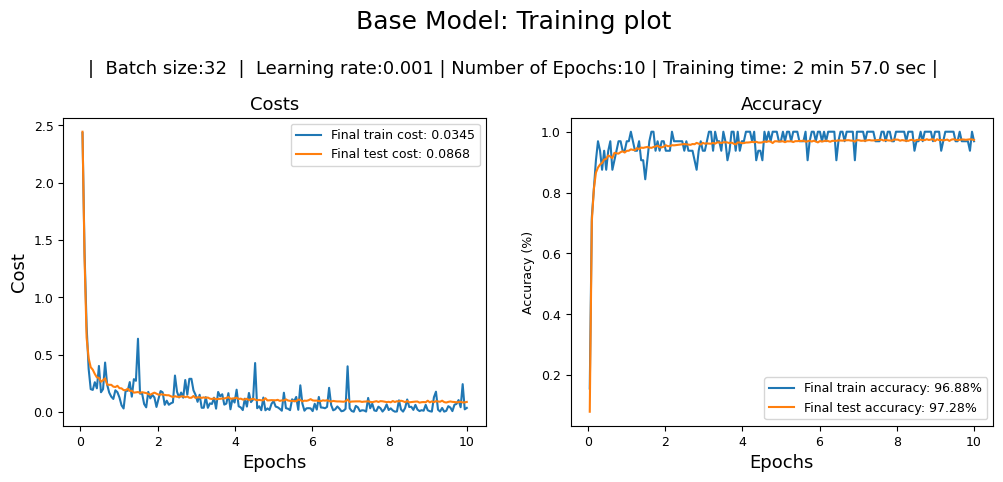

In [14]:
model_base.plot_loss_cost("Base Model: Training plot")

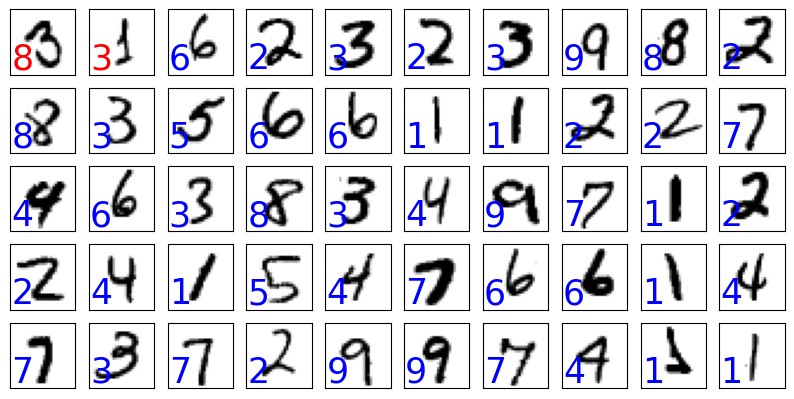

In [15]:
model_base.plot_predictions(test_dataset, 50)

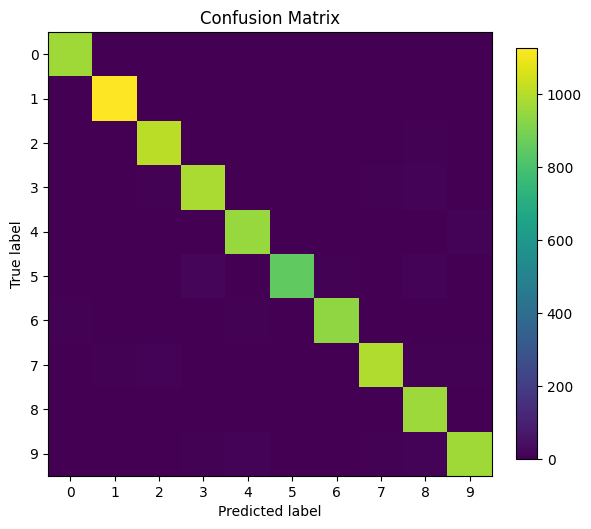

In [16]:
model_base.plot_confusion_matrix(test_dataset)

In [17]:

sum(p.numel() for p in model_base.model.parameters() if p.requires_grad)

344200

### Exercise 2: CNN

In [63]:
class CNN_Net(nn.Module):
    def __init__(self):
        super(CNN_Net, self).__init__()

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)

        self.flat = nn.Flatten()
        flat_dim = 32 * 7 * 7

        self.fc = nn.Linear(in_features=flat_dim, out_features=10)

        # network initialization
        self.apply(weight_init)

    def forward(self, input):
        # get back to image chape 1 x 28 x 28  (first dim = channels, =1 because grayscale)
        x = torch.reshape(input, (input.shape[0], int(math.sqrt(input.shape[1])), int(math.sqrt(input.shape[1]))))
        x = torch.unsqueeze(x,dim=1)
   
        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)

        x = self.relu(self.conv3(x))
        x = self.flat(x)

        x = self.fc(x)

        return x

In [64]:
learning_rate = 0.005
epochs = 5
batch_size = 32

model_2 = CNN_Net()

model_cnn = train_model(model_2,
                        learning_rate,
                        batch_size,
                        epochs,
                        train_dataset,
                        test_dataset,
                        device='cpu',
                        optimizer='SGD')

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch  0 - Step     0: train accuracy   9.38% train costs  2.30  test accuracy   8.80% test costs  2.31
Epoch  0 - Step   100: train accuracy  78.12% train costs  0.78  test accuracy  72.42% test costs  0.90
Epoch  0 - Step   200: train accuracy  78.12% train costs  0.44  test accuracy  86.16% test costs  0.42
Epoch  0 - Step   300: train accuracy  90.62% train costs  0.31  test accuracy  92.49% test costs  0.26
Epoch  0 - Step   400: train accuracy  90.62% train costs  0.33  test accuracy  93.56% test costs  0.22
Epoch  0 - Step   500: train accuracy 100.00% train costs  0.06  test accuracy  93.48% test costs  0.20
Epoch  0 - Step   600: train accuracy  93.75% train costs  0.17  test accuracy  95.50% test costs  0.15
Epoch  0 - Step   700: train accuracy  84.38% train costs  0.53  test accuracy  95.71% test costs  0.14
Epoch  0 - Step   800: train accuracy  90.62% train costs  0.17  test accuracy  96.38% test costs  0.11
Epoch  0 - Step   900: train accuracy 100.00% train costs  0.04 

Training:  20%|██        | 1/5 [01:02<04:10, 62.52s/it]

Epoch  1 - Step  1900: train accuracy 100.00% train costs  0.01  test accuracy  97.81% test costs  0.07
Epoch  1 - Step  2000: train accuracy  96.88% train costs  0.07  test accuracy  97.84% test costs  0.07
Epoch  1 - Step  2100: train accuracy  96.88% train costs  0.06  test accuracy  97.77% test costs  0.07
Epoch  1 - Step  2200: train accuracy  96.88% train costs  0.11  test accuracy  98.01% test costs  0.07
Epoch  1 - Step  2300: train accuracy 100.00% train costs  0.01  test accuracy  98.19% test costs  0.06
Epoch  1 - Step  2400: train accuracy  96.88% train costs  0.14  test accuracy  97.65% test costs  0.07
Epoch  1 - Step  2500: train accuracy 100.00% train costs  0.01  test accuracy  97.62% test costs  0.07
Epoch  1 - Step  2600: train accuracy  96.88% train costs  0.06  test accuracy  97.95% test costs  0.06
Epoch  1 - Step  2700: train accuracy 100.00% train costs  0.00  test accuracy  98.22% test costs  0.05
Epoch  1 - Step  2800: train accuracy 100.00% train costs  0.00 

Training:  40%|████      | 2/5 [02:04<03:06, 62.15s/it]

...

Training:  60%|██████    | 3/5 [03:04<02:02, 61.41s/it]

Epoch  3 - Step  5700: train accuracy 100.00% train costs  0.03  test accuracy  98.87% test costs  0.04
Epoch  3 - Step  5800: train accuracy 100.00% train costs  0.00  test accuracy  98.49% test costs  0.04
Epoch  3 - Step  5900: train accuracy 100.00% train costs  0.01  test accuracy  98.60% test costs  0.05
Epoch  3 - Step  6000: train accuracy  96.88% train costs  0.13  test accuracy  98.62% test costs  0.04
Epoch  3 - Step  6100: train accuracy 100.00% train costs  0.02  test accuracy  98.32% test costs  0.05
Epoch  3 - Step  6200: train accuracy 100.00% train costs  0.03  test accuracy  98.68% test costs  0.04
Epoch  3 - Step  6300: train accuracy 100.00% train costs  0.01  test accuracy  98.84% test costs  0.04
Epoch  3 - Step  6400: train accuracy 100.00% train costs  0.01  test accuracy  98.41% test costs  0.05
Epoch  3 - Step  6500: train accuracy 100.00% train costs  0.01  test accuracy  98.73% test costs  0.04
Epoch  3 - Step  6600: train accuracy 100.00% train costs  0.01 

Training:  80%|████████  | 4/5 [04:02<00:59, 59.90s/it]

Epoch  4 - Step  7500: train accuracy 100.00% train costs  0.03  test accuracy  98.69% test costs  0.04
Epoch  4 - Step  7600: train accuracy  96.88% train costs  0.04  test accuracy  98.77% test costs  0.04
Epoch  4 - Step  7700: train accuracy 100.00% train costs  0.01  test accuracy  98.78% test costs  0.04
Epoch  4 - Step  7800: train accuracy 100.00% train costs  0.01  test accuracy  98.80% test costs  0.04
Epoch  4 - Step  7900: train accuracy 100.00% train costs  0.02  test accuracy  98.84% test costs  0.04
Epoch  4 - Step  8000: train accuracy  96.88% train costs  0.14  test accuracy  98.82% test costs  0.04
Epoch  4 - Step  8100: train accuracy 100.00% train costs  0.01  test accuracy  98.83% test costs  0.04
Epoch  4 - Step  8200: train accuracy 100.00% train costs  0.00  test accuracy  98.74% test costs  0.04
Epoch  4 - Step  8300: train accuracy 100.00% train costs  0.03  test accuracy  98.69% test costs  0.04
Epoch  4 - Step  8400: train accuracy 100.00% train costs  0.00 

Training: 100%|██████████| 5/5 [05:01<00:00, 60.23s/it]


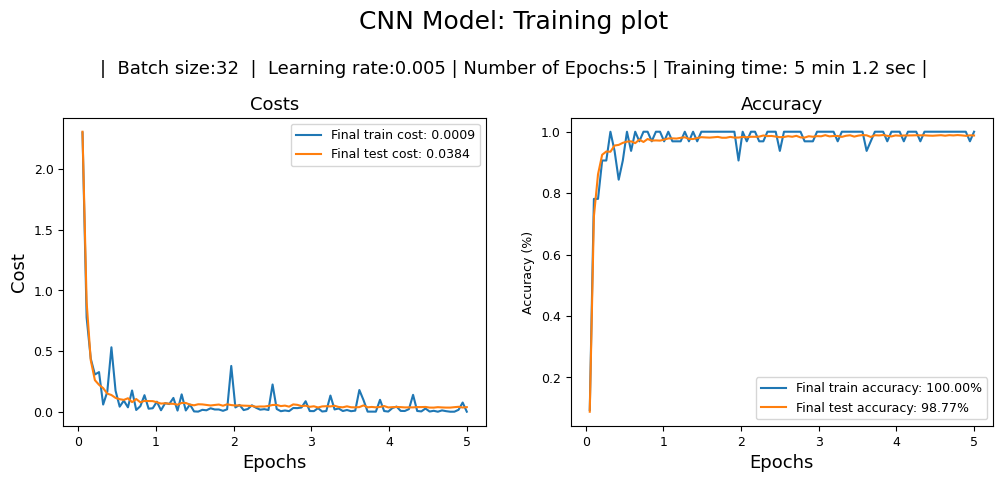

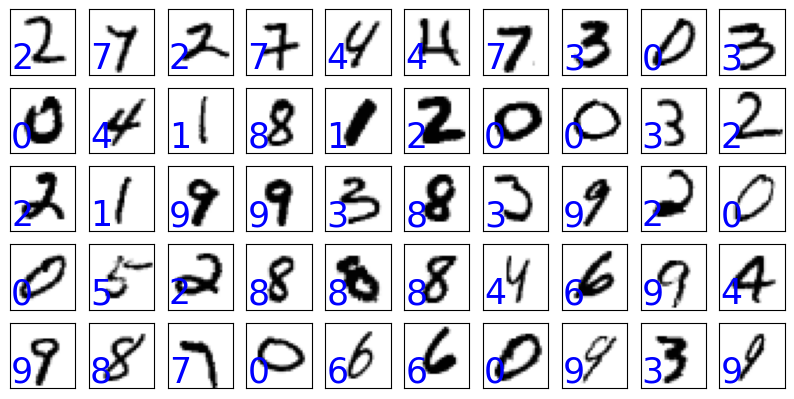

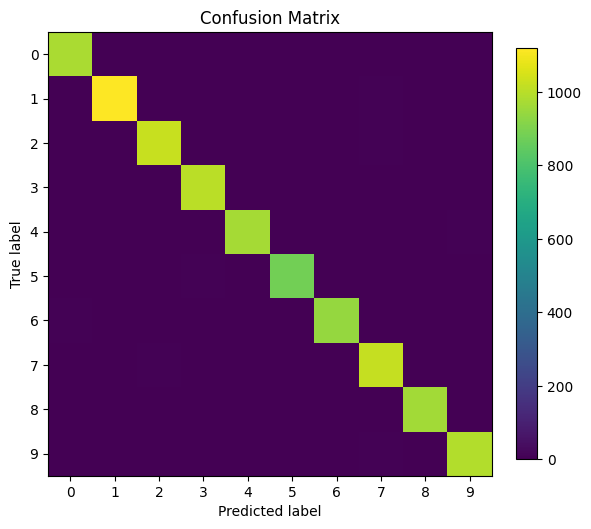

In [68]:
model_cnn.plot_loss_cost("CNN Model: Training plot")
model_cnn.plot_predictions(test_dataset, 50)
model_cnn.plot_confusion_matrix(test_dataset)

In [66]:
sum(p.numel() for p in model_cnn.model.parameters() if p.requires_grad)

21578

In [69]:
learning_rate = 0.005
epochs = 5
batch_size = 32

model_3 = CNN_Net()

model_cnn_adam = train_model(model_3,
                        learning_rate,
                        batch_size,
                        epochs,
                        train_dataset,
                        test_dataset,
                        device='cpu',
                        optimizer="Adam")

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch  0 - Step     0: train accuracy   3.12% train costs  2.34  test accuracy  14.87% test costs  2.32
Epoch  0 - Step   100: train accuracy  93.75% train costs  0.17  test accuracy  94.11% test costs  0.20
Epoch  0 - Step   200: train accuracy  93.75% train costs  0.39  test accuracy  94.26% test costs  0.18
Epoch  0 - Step   300: train accuracy  93.75% train costs  0.26  test accuracy  94.70% test costs  0.16
Epoch  0 - Step   400: train accuracy 100.00% train costs  0.03  test accuracy  95.03% test costs  0.15
Epoch  0 - Step   500: train accuracy  96.88% train costs  0.09  test accuracy  97.48% test costs  0.08
Epoch  0 - Step   600: train accuracy  93.75% train costs  0.12  test accuracy  97.73% test costs  0.07
Epoch  0 - Step   700: train accuracy  96.88% train costs  0.13  test accuracy  97.77% test costs  0.08
Epoch  0 - Step   800: train accuracy  96.88% train costs  0.16  test accuracy  97.30% test costs  0.08
Epoch  0 - Step   900: train accuracy  96.88% train costs  0.18 

Training:  20%|██        | 1/5 [01:09<04:38, 69.56s/it]

Epoch  1 - Step  1900: train accuracy 100.00% train costs  0.02  test accuracy  98.27% test costs  0.06
Epoch  1 - Step  2000: train accuracy 100.00% train costs  0.02  test accuracy  98.23% test costs  0.05
Epoch  1 - Step  2100: train accuracy  96.88% train costs  0.05  test accuracy  98.21% test costs  0.06
Epoch  1 - Step  2200: train accuracy  96.88% train costs  0.04  test accuracy  98.11% test costs  0.06
Epoch  1 - Step  2300: train accuracy  96.88% train costs  0.04  test accuracy  98.34% test costs  0.05
Epoch  1 - Step  2400: train accuracy 100.00% train costs  0.00  test accuracy  98.44% test costs  0.06
Epoch  1 - Step  2500: train accuracy  96.88% train costs  0.04  test accuracy  97.88% test costs  0.07
Epoch  1 - Step  2600: train accuracy  96.88% train costs  0.05  test accuracy  98.46% test costs  0.04
Epoch  1 - Step  2700: train accuracy 100.00% train costs  0.00  test accuracy  98.56% test costs  0.04
Epoch  1 - Step  2800: train accuracy  96.88% train costs  0.12 

Training:  40%|████      | 2/5 [02:22<03:35, 71.67s/it]

...

Training:  60%|██████    | 3/5 [03:32<02:21, 70.98s/it]

Epoch  3 - Step  5700: train accuracy 100.00% train costs  0.00  test accuracy  98.71% test costs  0.04
Epoch  3 - Step  5800: train accuracy 100.00% train costs  0.00  test accuracy  98.75% test costs  0.04
Epoch  3 - Step  5900: train accuracy 100.00% train costs  0.01  test accuracy  98.29% test costs  0.06
Epoch  3 - Step  6000: train accuracy 100.00% train costs  0.01  test accuracy  98.51% test costs  0.05
Epoch  3 - Step  6100: train accuracy 100.00% train costs  0.00  test accuracy  98.63% test costs  0.04
Epoch  3 - Step  6200: train accuracy  96.88% train costs  0.03  test accuracy  98.65% test costs  0.04
Epoch  3 - Step  6300: train accuracy 100.00% train costs  0.01  test accuracy  98.49% test costs  0.05
Epoch  3 - Step  6400: train accuracy 100.00% train costs  0.00  test accuracy  98.67% test costs  0.04
Epoch  3 - Step  6500: train accuracy 100.00% train costs  0.00  test accuracy  98.62% test costs  0.04
Epoch  3 - Step  6600: train accuracy 100.00% train costs  0.02 

Training:  80%|████████  | 4/5 [04:43<01:10, 70.99s/it]

Epoch  4 - Step  7500: train accuracy 100.00% train costs  0.00  test accuracy  98.55% test costs  0.05
Epoch  4 - Step  7600: train accuracy 100.00% train costs  0.00  test accuracy  98.73% test costs  0.04
Epoch  4 - Step  7700: train accuracy 100.00% train costs  0.01  test accuracy  98.05% test costs  0.06
Epoch  4 - Step  7800: train accuracy  96.88% train costs  0.10  test accuracy  98.61% test costs  0.05
Epoch  4 - Step  7900: train accuracy  96.88% train costs  0.08  test accuracy  98.62% test costs  0.05
Epoch  4 - Step  8000: train accuracy 100.00% train costs  0.00  test accuracy  98.45% test costs  0.06
Epoch  4 - Step  8100: train accuracy 100.00% train costs  0.00  test accuracy  98.25% test costs  0.06
Epoch  4 - Step  8200: train accuracy 100.00% train costs  0.00  test accuracy  98.59% test costs  0.05
Epoch  4 - Step  8300: train accuracy 100.00% train costs  0.01  test accuracy  98.31% test costs  0.06
Epoch  4 - Step  8400: train accuracy 100.00% train costs  0.01 

Training: 100%|██████████| 5/5 [05:52<00:00, 70.46s/it]


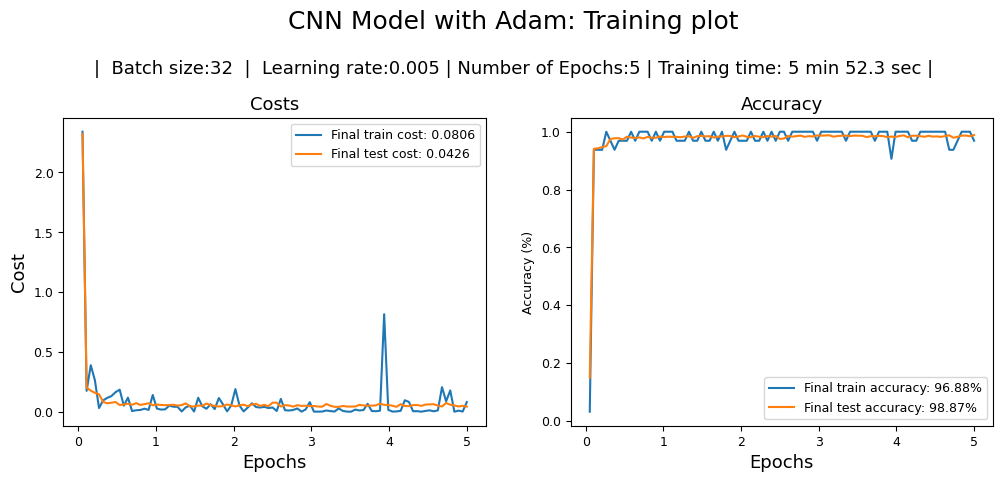

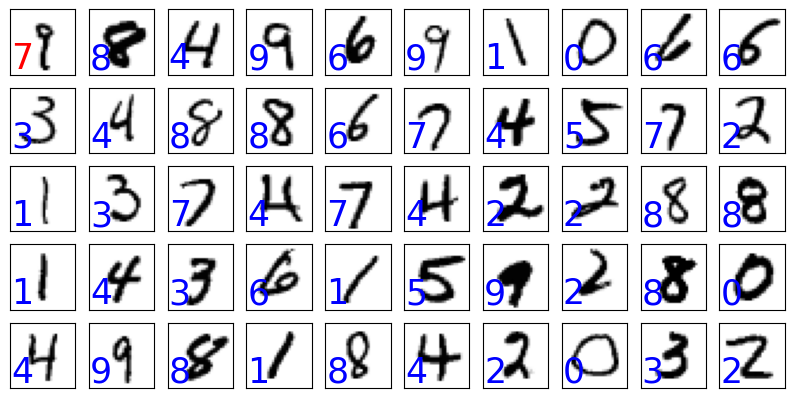

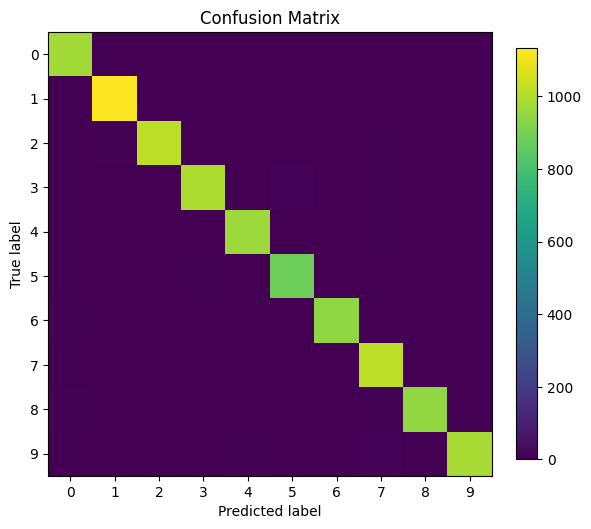

In [70]:
model_cnn_adam.plot_loss_cost("CNN Model with Adam: Training plot")
model_cnn_adam.plot_predictions(test_dataset, 50)
model_cnn_adam.plot_confusion_matrix(test_dataset)

###  Exercise 4. Residual connections
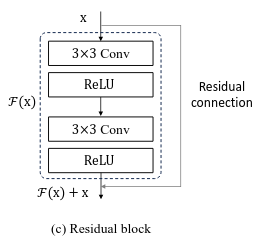

In [ ]:
class CNN_Res_Net(nn.Module):
    def __init__(self):
        super(CNN_Res_Net, self).__init__()

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1)

        self.flat = nn.Flatten()
        flat_dim = 16 * 28 * 28

        self.fc = nn.Linear(in_features=flat_dim, out_features=10)

        # network initialization
        self.apply(weight_init)

    def forward(self, input):
        # get back to image chape 1 x 28 x 28  (first dim = channels, =1 because grayscale)
        x = torch.reshape(input, (input.shape[0], int(math.sqrt(input.shape[1])), int(math.sqrt(input.shape[1]))))
        x = torch.unsqueeze(x,dim=1)

        residual = x
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))

        x = x+residual

        x = self.flat(x)
        x = self.fc(x)

        return x

In [79]:
learning_rate = 0.005
epochs = 5
batch_size = 32

model_4 = CNN_Res_Net()

model_cnn_res = train_model(model_4,
                        learning_rate,
                        batch_size,
                        epochs,
                        train_dataset,
                        test_dataset,
                        device='cpu')

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch  0 - Step     0: train accuracy   9.38% train costs  2.47  test accuracy  11.21% test costs  2.42
Epoch  0 - Step   100: train accuracy  78.12% train costs  0.77  test accuracy  86.76% test costs  0.45
Epoch  0 - Step   200: train accuracy  84.38% train costs  0.48  test accuracy  88.22% test costs  0.40
Epoch  0 - Step   300: train accuracy  93.75% train costs  0.19  test accuracy  89.59% test costs  0.37
Epoch  0 - Step   400: train accuracy  93.75% train costs  0.30  test accuracy  88.20% test costs  0.41
Epoch  0 - Step   500: train accuracy  90.62% train costs  0.17  test accuracy  90.80% test costs  0.32
Epoch  0 - Step   600: train accuracy  87.50% train costs  0.50  test accuracy  90.42% test costs  0.33
Epoch  0 - Step   700: train accuracy 100.00% train costs  0.12  test accuracy  89.15% test costs  0.36
Epoch  0 - Step   800: train accuracy  96.88% train costs  0.22  test accuracy  90.20% test costs  0.34
Epoch  0 - Step   900: train accuracy  87.50% train costs  0.32 

Training:  20%|██        | 1/5 [01:34<06:16, 94.10s/it]

Epoch  1 - Step  1900: train accuracy  93.75% train costs  0.20  test accuracy  89.49% test costs  0.36
Epoch  1 - Step  2000: train accuracy  87.50% train costs  0.41  test accuracy  90.96% test costs  0.33
Epoch  1 - Step  2100: train accuracy  93.75% train costs  0.23  test accuracy  92.47% test costs  0.28
Epoch  1 - Step  2200: train accuracy  96.88% train costs  0.06  test accuracy  92.17% test costs  0.27
Epoch  1 - Step  2300: train accuracy  96.88% train costs  0.24  test accuracy  92.21% test costs  0.27
Epoch  1 - Step  2400: train accuracy  90.62% train costs  0.41  test accuracy  92.81% test costs  0.26
Epoch  1 - Step  2500: train accuracy  96.88% train costs  0.21  test accuracy  93.88% test costs  0.23
Epoch  1 - Step  2600: train accuracy  87.50% train costs  0.38  test accuracy  93.88% test costs  0.21
Epoch  1 - Step  2700: train accuracy  93.75% train costs  0.31  test accuracy  94.88% test costs  0.19
Epoch  1 - Step  2800: train accuracy  96.88% train costs  0.08 

Training:  40%|████      | 2/5 [03:01<04:30, 90.18s/it]

...

Training:  60%|██████    | 3/5 [04:26<02:55, 87.85s/it]

Epoch  3 - Step  5700: train accuracy  93.75% train costs  0.24  test accuracy  97.44% test costs  0.09
Epoch  3 - Step  5800: train accuracy  93.75% train costs  0.25  test accuracy  97.23% test costs  0.09
Epoch  3 - Step  5900: train accuracy  96.88% train costs  0.04  test accuracy  97.11% test costs  0.10
Epoch  3 - Step  6000: train accuracy 100.00% train costs  0.03  test accuracy  97.53% test costs  0.08
Epoch  3 - Step  6100: train accuracy 100.00% train costs  0.01  test accuracy  97.18% test costs  0.10
Epoch  3 - Step  6200: train accuracy  96.88% train costs  0.22  test accuracy  97.03% test costs  0.10
Epoch  3 - Step  6300: train accuracy  96.88% train costs  0.03  test accuracy  96.66% test costs  0.11
Epoch  3 - Step  6400: train accuracy  96.88% train costs  0.16  test accuracy  96.46% test costs  0.13
Epoch  3 - Step  6500: train accuracy 100.00% train costs  0.01  test accuracy  97.48% test costs  0.09
Epoch  3 - Step  6600: train accuracy  90.62% train costs  0.15 

Training:  80%|████████  | 4/5 [05:51<01:26, 86.86s/it]

Epoch  4 - Step  7500: train accuracy 100.00% train costs  0.02  test accuracy  97.35% test costs  0.09
Epoch  4 - Step  7600: train accuracy 100.00% train costs  0.01  test accuracy  97.89% test costs  0.07
Epoch  4 - Step  7700: train accuracy 100.00% train costs  0.01  test accuracy  97.70% test costs  0.08
Epoch  4 - Step  7800: train accuracy 100.00% train costs  0.01  test accuracy  97.84% test costs  0.07
Epoch  4 - Step  7900: train accuracy 100.00% train costs  0.02  test accuracy  97.95% test costs  0.07
Epoch  4 - Step  8000: train accuracy 100.00% train costs  0.00  test accuracy  97.55% test costs  0.09
Epoch  4 - Step  8100: train accuracy  93.75% train costs  0.07  test accuracy  97.59% test costs  0.09
Epoch  4 - Step  8200: train accuracy 100.00% train costs  0.01  test accuracy  97.22% test costs  0.09
Epoch  4 - Step  8300: train accuracy 100.00% train costs  0.00  test accuracy  97.37% test costs  0.09
Epoch  4 - Step  8400: train accuracy 100.00% train costs  0.02 

Training: 100%|██████████| 5/5 [07:17<00:00, 87.47s/it]


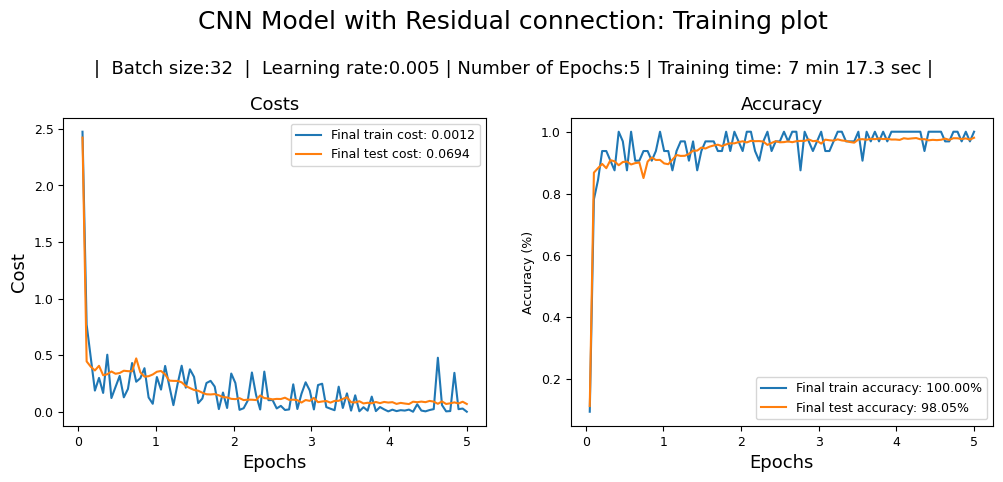

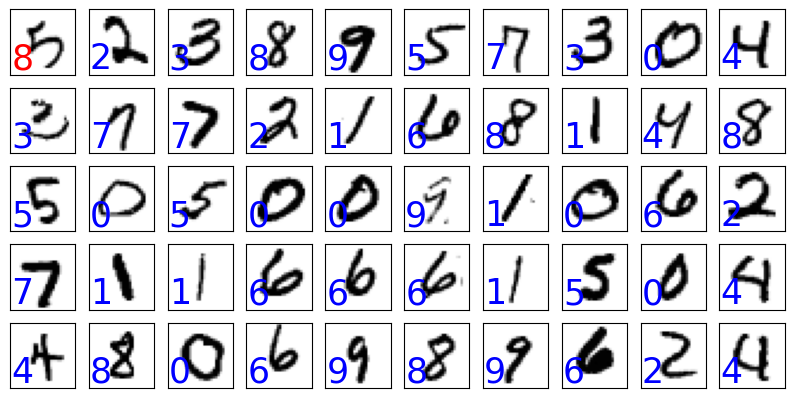

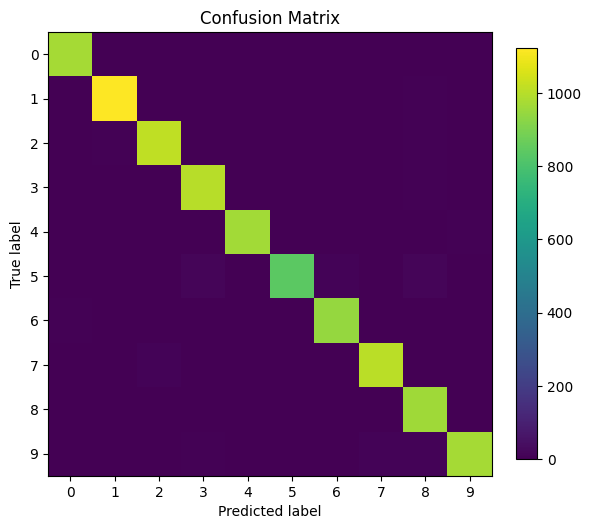

In [81]:
model_cnn_res.plot_loss_cost("CNN Model with Residual connection: Training plot")
model_cnn_res.plot_predictions(test_dataset, 50)
model_cnn_res.plot_confusion_matrix(test_dataset)

### Excercise 5: Regularization 

In [18]:
class CNN_BatchNorm_Net(nn.Module):
    def __init__(self):
        super(CNN_BatchNorm_Net, self).__init__()

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.conv1_bn = nn.BatchNorm2d(8)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.conv2_bn = nn.BatchNorm2d(16)

        self.flat = nn.Flatten()
        flat_dim = 16 * 28 * 28

        self.fc = nn.Linear(in_features=flat_dim, out_features=10)
        self.apply(weight_init)

    def forward(self, input):
        # get back to image chape 1 x 28 x 28  (first dim = channels, =1 because grayscale)
        x = torch.reshape(input, (input.shape[0], int(math.sqrt(input.shape[1])), int(math.sqrt(input.shape[1]))))
        x = torch.unsqueeze(x,dim=1)

        residual = x
        x = self.conv1(x)
        x = self.relu(self.conv1_bn(x))
        x = self.conv2(x)
        x = self.relu(self.conv2_bn(x))
        x = x+residual

        x = self.flat(x)
        x = self.fc(x)

        return x

In [23]:
learning_rate = 0.01
epochs = 5
batch_size = 32

model_4 = CNN_BatchNorm_Net()

model_cnn_batchnorm = train_model(model_4,
                        learning_rate,
                        batch_size,
                        epochs,
                        train_dataset,
                        test_dataset,
                        device='cpu')

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch  0 - Step     0: train accuracy   6.25% train costs  3.00  test accuracy  13.29% test costs  2.62
Epoch  0 - Step   100: train accuracy  90.62% train costs  0.20  test accuracy  86.19% test costs  0.51
Epoch  0 - Step   200: train accuracy  93.75% train costs  0.26  test accuracy  86.76% test costs  0.54
Epoch  0 - Step   300: train accuracy  84.38% train costs  0.62  test accuracy  87.89% test costs  0.50
Epoch  0 - Step   400: train accuracy  93.75% train costs  0.24  test accuracy  86.70% test costs  0.54
Epoch  0 - Step   500: train accuracy  75.00% train costs  0.45  test accuracy  85.99% test costs  0.54
Epoch  0 - Step   600: train accuracy  93.75% train costs  0.42  test accuracy  86.59% test costs  0.53
Epoch  0 - Step   700: train accuracy  90.62% train costs  0.81  test accuracy  87.04% test costs  0.52
Epoch  0 - Step   800: train accuracy  84.38% train costs  0.54  test accuracy  88.19% test costs  0.49
Epoch  0 - Step   900: train accuracy  78.12% train costs  0.88 

Training:  20%|██        | 1/5 [01:37<06:31, 97.88s/it]

Epoch  1 - Step  1900: train accuracy  96.88% train costs  0.12  test accuracy  92.53% test costs  0.31
Epoch  1 - Step  2000: train accuracy 100.00% train costs  0.02  test accuracy  94.84% test costs  0.22
Epoch  1 - Step  2100: train accuracy  90.62% train costs  0.44  test accuracy  94.09% test costs  0.24
Epoch  1 - Step  2200: train accuracy  87.50% train costs  0.36  test accuracy  93.48% test costs  0.28
Epoch  1 - Step  2300: train accuracy  93.75% train costs  0.08  test accuracy  94.29% test costs  0.24
Epoch  1 - Step  2400: train accuracy  93.75% train costs  0.22  test accuracy  95.61% test costs  0.20
Epoch  1 - Step  2500: train accuracy  93.75% train costs  0.22  test accuracy  94.75% test costs  0.25
Epoch  1 - Step  2600: train accuracy 100.00% train costs  0.01  test accuracy  95.78% test costs  0.18
Epoch  1 - Step  2700: train accuracy  96.88% train costs  0.20  test accuracy  95.09% test costs  0.22
Epoch  1 - Step  2800: train accuracy  93.75% train costs  0.42 

Training:  40%|████      | 2/5 [03:05<04:36, 92.09s/it]

...

Training:  60%|██████    | 3/5 [04:31<02:58, 89.29s/it]

Epoch  3 - Step  5700: train accuracy  96.88% train costs  0.15  test accuracy  96.51% test costs  0.15
Epoch  3 - Step  5800: train accuracy  96.88% train costs  0.39  test accuracy  95.81% test costs  0.22
Epoch  3 - Step  5900: train accuracy  96.88% train costs  0.07  test accuracy  96.53% test costs  0.16
Epoch  3 - Step  6000: train accuracy  93.75% train costs  0.47  test accuracy  96.94% test costs  0.14
Epoch  3 - Step  6100: train accuracy  96.88% train costs  0.35  test accuracy  96.11% test costs  0.19
Epoch  3 - Step  6200: train accuracy  93.75% train costs  0.68  test accuracy  96.81% test costs  0.15
Epoch  3 - Step  6300: train accuracy 100.00% train costs  0.02  test accuracy  97.42% test costs  0.12
Epoch  3 - Step  6400: train accuracy  93.75% train costs  0.22  test accuracy  97.32% test costs  0.11
Epoch  3 - Step  6500: train accuracy  93.75% train costs  0.12  test accuracy  96.65% test costs  0.15
Epoch  3 - Step  6600: train accuracy  96.88% train costs  0.16 

Training:  80%|████████  | 4/5 [05:50<01:25, 85.19s/it]

Epoch  4 - Step  7500: train accuracy  96.88% train costs  0.05  test accuracy  96.18% test costs  0.17
Epoch  4 - Step  7600: train accuracy  93.75% train costs  0.24  test accuracy  96.87% test costs  0.14
Epoch  4 - Step  7700: train accuracy  90.62% train costs  0.22  test accuracy  97.72% test costs  0.10
Epoch  4 - Step  7800: train accuracy  96.88% train costs  0.33  test accuracy  97.07% test costs  0.13
Epoch  4 - Step  7900: train accuracy  96.88% train costs  0.07  test accuracy  96.78% test costs  0.16
Epoch  4 - Step  8000: train accuracy  93.75% train costs  0.30  test accuracy  97.30% test costs  0.13
Epoch  4 - Step  8100: train accuracy 100.00% train costs  0.01  test accuracy  97.84% test costs  0.09
Epoch  4 - Step  8200: train accuracy  93.75% train costs  0.35  test accuracy  96.28% test costs  0.19
Epoch  4 - Step  8300: train accuracy  90.62% train costs  0.50  test accuracy  97.47% test costs  0.12
Epoch  4 - Step  8400: train accuracy  96.88% train costs  0.06 

Training: 100%|██████████| 5/5 [07:16<00:00, 87.22s/it]


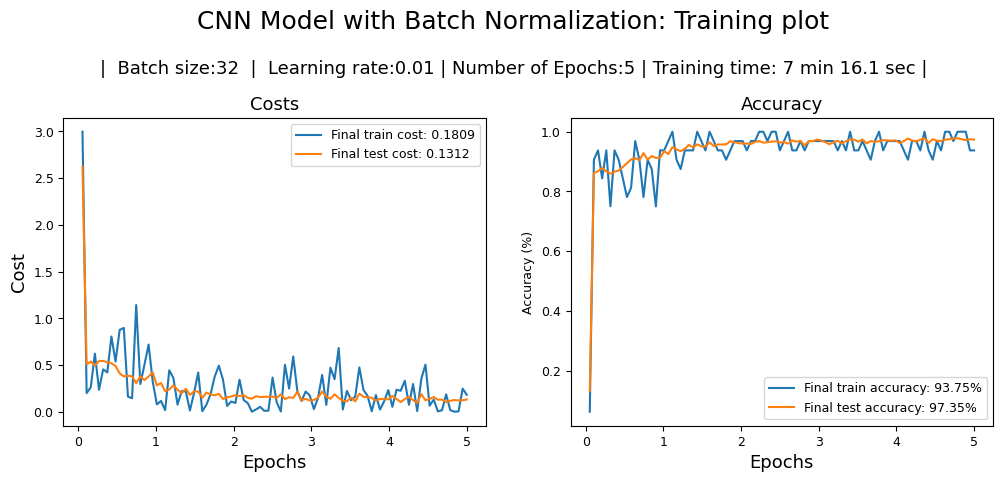

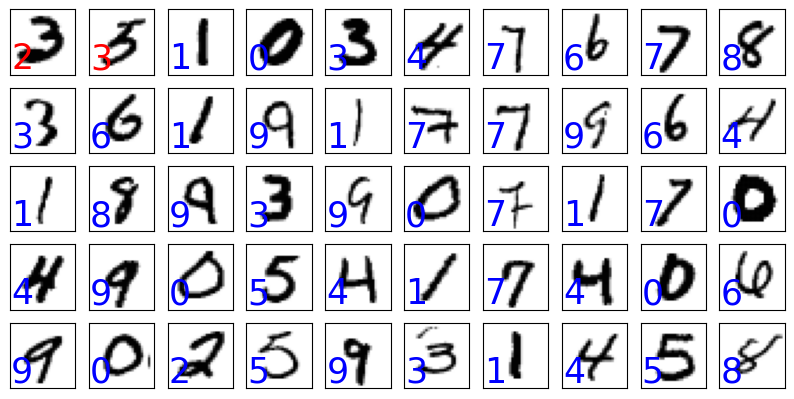

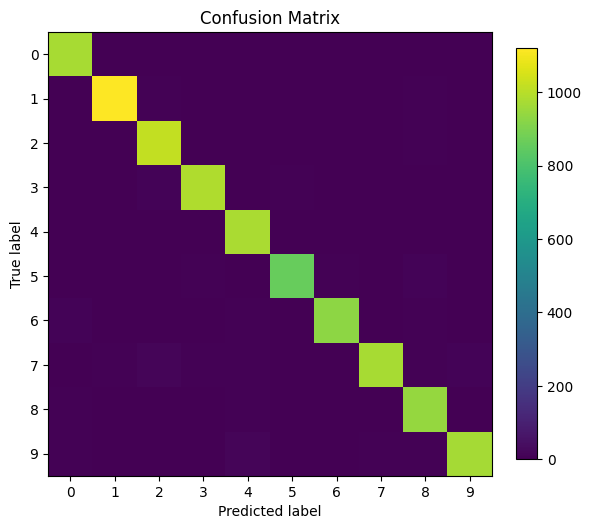

In [27]:
model_cnn_batchnorm.plot_loss_cost("CNN Model with Batch Normalization: Training plot")
model_cnn_batchnorm.plot_predictions(test_dataset, 50)
model_cnn_batchnorm.plot_confusion_matrix(test_dataset)

In [ ]:
class CNN_Dropout_Net(nn.Module):
    def __init__(self):
        super(CNN_Dropout_Net, self).__init__()

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.dropout = nn.Dropout2d(p=0.3)

        self.flat = nn.Flatten()
        flat_dim = 16 * 28 * 28

        self.fc = nn.Linear(in_features=flat_dim, out_features=10)
        self.apply(weight_init)

    def forward(self, input):
        # get back to image chape 1 x 28 x 28  (first dim = channels, =1 because grayscale)
        x = torch.reshape(input, (input.shape[0], int(math.sqrt(input.shape[1])), int(math.sqrt(input.shape[1]))))
        x = torch.unsqueeze(x,dim=1)

        residual = x
        x = self.relu(self.conv1(x))
        x = self.dropout(x)
        x = self.relu(self.conv2(x))            
        x = self.dropout(x)
        x = x+residual

        x = self.flat(x)
        x = self.fc(x)
        #x = self.dropout(x)
        

        return x

In [38]:
learning_rate = 0.005
epochs = 5
batch_size = 64

model_5 = CNN_Dropout_Net()

model_cnn_dropout = train_model(model_5,
                        learning_rate,
                        batch_size,
                        epochs,
                        train_dataset,
                        test_dataset,
                        device='cpu')

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch  0 - Step     0: train accuracy  14.06% train costs  2.39  test accuracy  17.88% test costs  2.27
Epoch  0 - Step   100: train accuracy  90.62% train costs  0.29  test accuracy  88.39% test costs  0.39
Epoch  0 - Step   200: train accuracy  89.06% train costs  0.35  test accuracy  89.28% test costs  0.37
Epoch  0 - Step   300: train accuracy  85.94% train costs  0.47  test accuracy  91.14% test costs  0.31
Epoch  0 - Step   400: train accuracy  93.75% train costs  0.21  test accuracy  89.89% test costs  0.34
Epoch  0 - Step   500: train accuracy  89.06% train costs  0.53  test accuracy  91.15% test costs  0.31
Epoch  0 - Step   600: train accuracy  95.31% train costs  0.33  test accuracy  91.34% test costs  0.30
Epoch  0 - Step   700: train accuracy  85.94% train costs  0.81  test accuracy  91.41% test costs  0.29
Epoch  0 - Step   800: train accuracy  92.19% train costs  0.16  test accuracy  92.11% test costs  0.27
Epoch  0 - Step   900: train accuracy  92.19% train costs  0.17 

Training:  20%|██        | 1/5 [00:52<03:31, 52.82s/it]

Epoch  1 - Step  1000: train accuracy  87.50% train costs  0.41  test accuracy  92.66% test costs  0.26
Epoch  1 - Step  1100: train accuracy  96.88% train costs  0.15  test accuracy  92.86% test costs  0.25
Epoch  1 - Step  1200: train accuracy  90.62% train costs  0.21  test accuracy  93.62% test costs  0.22
Epoch  1 - Step  1300: train accuracy  96.88% train costs  0.11  test accuracy  93.99% test costs  0.21
Epoch  1 - Step  1400: train accuracy  89.06% train costs  0.49  test accuracy  94.05% test costs  0.21
Epoch  1 - Step  1500: train accuracy  90.62% train costs  0.46  test accuracy  95.02% test costs  0.17
Epoch  1 - Step  1600: train accuracy  95.31% train costs  0.12  test accuracy  95.52% test costs  0.16
Epoch  1 - Step  1700: train accuracy  95.31% train costs  0.18  test accuracy  95.35% test costs  0.16
Epoch  1 - Step  1800: train accuracy  90.62% train costs  0.16  test accuracy  95.99% test costs  0.14


Training:  40%|████      | 2/5 [01:50<02:46, 55.51s/it]

...

Training:  60%|██████    | 3/5 [02:52<01:57, 58.72s/it]

Epoch  3 - Step  2900: train accuracy  96.88% train costs  0.05  test accuracy  97.36% test costs  0.09
Epoch  3 - Step  3000: train accuracy  96.88% train costs  0.11  test accuracy  97.10% test costs  0.10
Epoch  3 - Step  3100: train accuracy  96.88% train costs  0.12  test accuracy  97.74% test costs  0.07
Epoch  3 - Step  3200: train accuracy  96.88% train costs  0.11  test accuracy  97.68% test costs  0.07
Epoch  3 - Step  3300: train accuracy  93.75% train costs  0.19  test accuracy  97.74% test costs  0.07
Epoch  3 - Step  3400: train accuracy  98.44% train costs  0.12  test accuracy  97.68% test costs  0.08
Epoch  3 - Step  3500: train accuracy 100.00% train costs  0.02  test accuracy  97.58% test costs  0.08
Epoch  3 - Step  3600: train accuracy  96.88% train costs  0.05  test accuracy  97.48% test costs  0.09
Epoch  3 - Step  3700: train accuracy  98.44% train costs  0.05  test accuracy  97.42% test costs  0.08


Training:  80%|████████  | 4/5 [03:49<00:57, 57.78s/it]

Epoch  4 - Step  3800: train accuracy  96.88% train costs  0.08  test accuracy  97.62% test costs  0.08
Epoch  4 - Step  3900: train accuracy  98.44% train costs  0.09  test accuracy  97.62% test costs  0.08
Epoch  4 - Step  4000: train accuracy  98.44% train costs  0.03  test accuracy  97.73% test costs  0.08
Epoch  4 - Step  4100: train accuracy  98.44% train costs  0.05  test accuracy  97.75% test costs  0.07
Epoch  4 - Step  4200: train accuracy  96.88% train costs  0.04  test accuracy  97.61% test costs  0.08
Epoch  4 - Step  4300: train accuracy  96.88% train costs  0.10  test accuracy  97.32% test costs  0.08
Epoch  4 - Step  4400: train accuracy  98.44% train costs  0.03  test accuracy  97.25% test costs  0.09
Epoch  4 - Step  4500: train accuracy  96.88% train costs  0.07  test accuracy  97.48% test costs  0.08
Epoch  4 - Step  4600: train accuracy 100.00% train costs  0.01  test accuracy  97.91% test costs  0.07


Training: 100%|██████████| 5/5 [04:47<00:00, 57.44s/it]


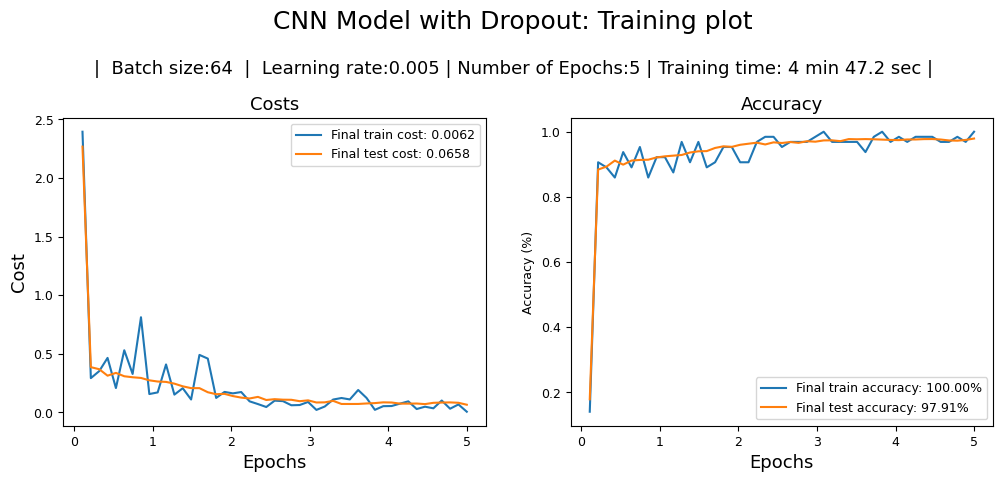

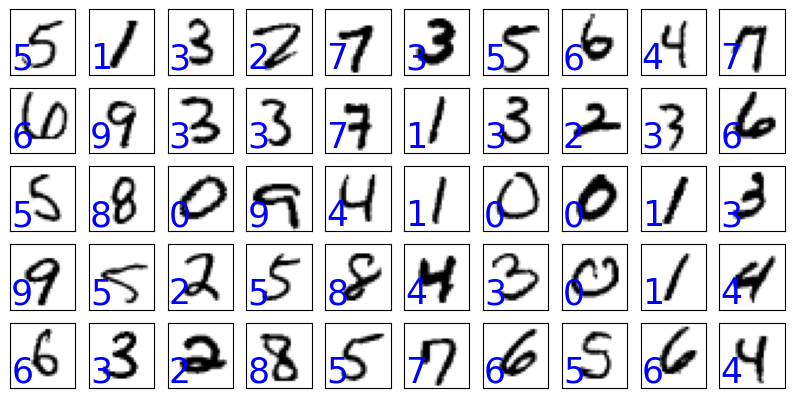

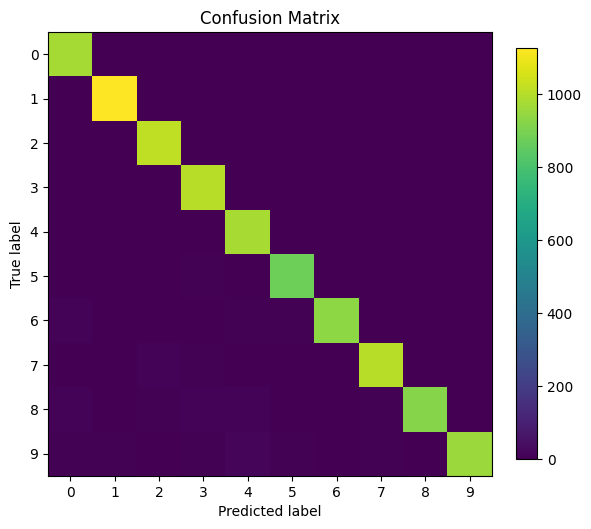

In [40]:
model_cnn_dropout.plot_loss_cost("CNN Model with Dropout: Training plot")
model_cnn_dropout.plot_predictions(test_dataset, 50)
model_cnn_dropout.plot_confusion_matrix(test_dataset)

In [83]:
# Plot 10 misclassified samples

def plot_wrong_predictions(model, testset):

        # evaluate the network on 100 random test images
        with torch.no_grad():
            # obtain 100 random samples from the test data set
            X, Y = next(iter(torch.utils.data.DataLoader(testset, batch_size=len(testset), shuffle=True)))

            # compute the predictions for the sampled inputs
            Yhat = predict(model, X)
            print("Yhan.length = ", len(Yhat))

            # sort the predictions with the incorrect ones first
            indices_incorrect= (Yhat == Y.argmax(dim=1)).float().argsort()[0:10]
            print("Yindices_incorrect ", len(indices_incorrect))
            print(indices_incorrect)


        # plot the images
        num_rows = 2
        num_cols = 5
        num_images = num_rows * num_cols
        plt.figure(figsize=(num_cols * 2, num_rows * 2))
        for i, index in enumerate(indices_incorrect, 1):
            plt.subplot(num_rows, num_cols, i)
            plt.xticks([])
            plt.yticks([])

            # plot the image
            plt.imshow(X[index, :].view(28, 28).cpu().numpy(), cmap=plt.cm.binary)

            # add the prediction as annotation (incorrect predictions in red, correct ones in blue)
            plt.title(
                f"True: {Y[index].argmax()} | Pred: {Yhat[index].item()}",
                fontsize=12)
        plt.show()

Yhan.length =  10000
Yindices_incorrect  10
tensor([9152, 3064, 4215, 1535, 4217, 4527,  555, 5873, 9775, 4536])


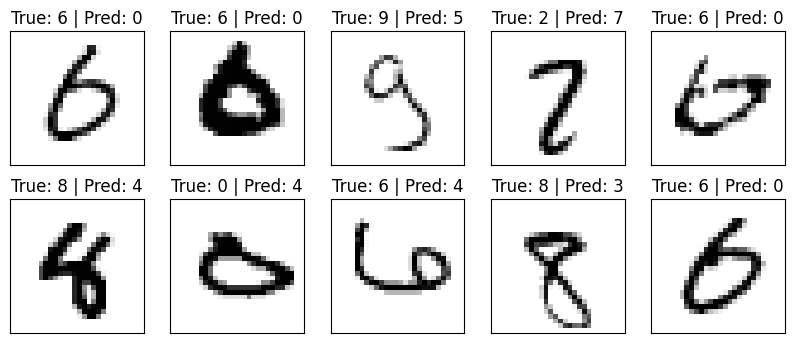

In [84]:
plot_wrong_predictions(model_cnn_dropout.model, test_dataset)